## Modelo de precificação de ativos

In [1]:
import pandas as pd
import numpy as np 
import math
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
import plotly.express as px

In [2]:
df = (pd.read_csv('acoes.csv').rename(columns={'Unnamed: 0': 'Date'}))
# df = df.rename(columns={'Unnamed: 0': 'Date'})
print(df.shape)
df.head()

(1037, 7)


,Date,VALE3.SA,PETR4.SA,BBDC4.SA,ABEV3.SA,EMBR3.SA,BOVA11.SA
0,2021-01-04,91.46,28.91,26.43,15.48,8.37,114.09
1,2021-01-05,93.00,30.04,26.25,15.81,8.57,114.69
2,2021-01-06,96.05,30.10,27.12,16.05,8.90,114.55
3,2021-01-07,102.32,31.00,27.84,16.05,8.88,118.37
4,2021-01-08,102.00,31.12,27.60,16.53,8.81,120.40


In [3]:
df.drop(labels = ['Date'], axis = 1, inplace = True)

In [7]:
dataset_normalizado = df.copy()
for i in df.columns:
  dataset_normalizado[i] = df[i] / df[i][0]
dataset_normalizado.head()

,VALE3.SA,PETR4.SA,BBDC4.SA,ABEV3.SA,EMBR3.SA,BOVA11.SA
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,1.016838,1.039087,0.993190,1.021318,1.023895,1.005259
2,1.050186,1.041162,1.026107,1.036822,1.063321,1.004032
3,1.118740,1.072293,1.053348,1.036822,1.060932,1.037514
4,1.115242,1.076444,1.044268,1.067829,1.052569,1.055307


In [8]:
dataset_taxa_retorno = (dataset_normalizado / dataset_normalizado.shift(1)) - 1
dataset_taxa_retorno.head()

,VALE3.SA,PETR4.SA,BBDC4.SA,ABEV3.SA,EMBR3.SA,BOVA11.SA
0,NaN,NaN,NaN,NaN,NaN,NaN
1,0.016838,0.039087,-0.006810,0.021318,0.023895,0.005259
2,0.032796,0.001997,0.033143,0.015180,0.038506,-0.001221
3,0.065279,0.029900,0.026549,0.000000,-0.002247,0.033348
4,-0.003127,0.003871,-0.008621,0.029907,-0.007883,0.017150


In [9]:
dataset_taxa_retorno.fillna(0, inplace=True)
dataset_taxa_retorno.head()

,VALE3.SA,PETR4.SA,BBDC4.SA,ABEV3.SA,EMBR3.SA,BOVA11.SA
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.016838,0.039087,-0.006810,0.021318,0.023895,0.005259
2,0.032796,0.001997,0.033143,0.015180,0.038506,-0.001221
3,0.065279,0.029900,0.026549,0.000000,-0.002247,0.033348
4,-0.003127,0.003871,-0.008621,0.029907,-0.007883,0.017150


In [10]:
dataset_taxa_retorno.mean() * 246

VALE3.SA    -0.070385
PETR4.SA     0.124105
BBDC4.SA    -0.154032
ABEV3.SA    -0.026280
EMBR3.SA     0.603511
BOVA11.SA    0.029800
dtype: float64

### Cálculo do parâmetro BETA para um ativo

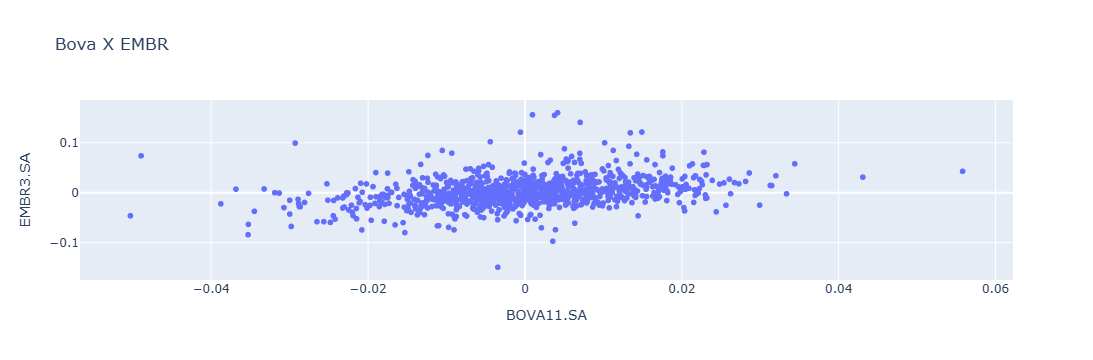

In [12]:
fig = px.scatter(dataset_taxa_retorno, x='BOVA11.SA', y='EMBR3.SA', title='Bova X EMBR')
fig.show()

In [17]:
beta, alpha = np.polyfit(x = dataset_taxa_retorno['BOVA11.SA'], y = dataset_taxa_retorno['EMBR3.SA'], deg=1)
print('Beta:', beta,'/', 'Aplha:', alpha,'/', 'Aplha %:', alpha * 100)

Beta: 0.7720354055868083 / Aplha: 0.0023597744346563285 / Aplha %: 0.23597744346563285


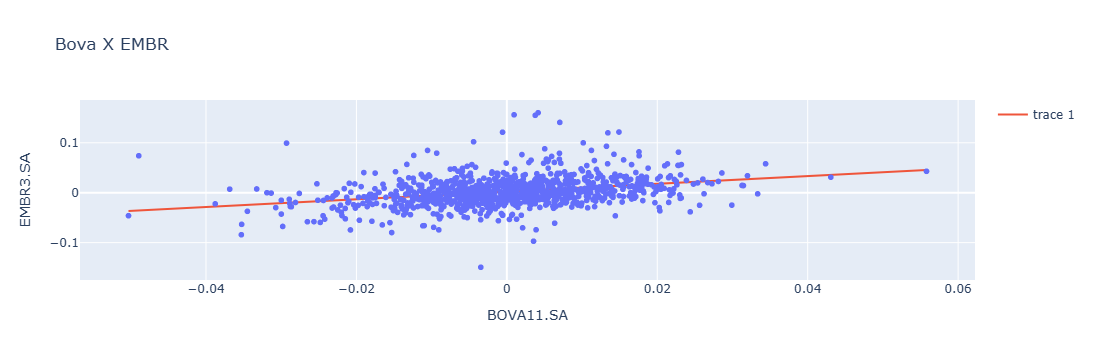

In [18]:
fig = px.scatter(dataset_taxa_retorno, x='BOVA11.SA', y='EMBR3.SA', title='Bova X EMBR')
fig.add_scatter(x = dataset_taxa_retorno['BOVA11.SA'], y= beta * dataset_taxa_retorno['BOVA11.SA'] + alpha)
fig.show()

### BETA com covariância e variância

In [19]:
dataset_taxa_retorno.columns

Index(['VALE3.SA', 'PETR4.SA', 'BBDC4.SA', 'ABEV3.SA', 'EMBR3.SA',
       'BOVA11.SA'],
      dtype='object')

In [21]:
matriz_covariancia = dataset_taxa_retorno.drop(columns=['VALE3.SA', 'PETR4.SA', 'BBDC4.SA', 'ABEV3.SA']).cov() * 246
matriz_covariancia

,EMBR3.SA,BOVA11.SA
EMBR3.SA,0.203294,0.027293
BOVA11.SA,0.027293,0.035352


In [23]:
cov_embr_bova = matriz_covariancia.iloc[1, 0]
cov_embr_bova

0.027292840540816852

In [25]:
var_bova = dataset_taxa_retorno['BOVA11.SA'].var() * 246
var_bova

0.03535179907982603

In [28]:
beta_embr = cov_embr_bova / var_bova
# (beta_embr - 1) * 100
beta_embr

0.7720354055868085

### Cálculo CAPM para uma ação

In [31]:
beta 

0.7720354055868083

In [34]:
rm = dataset_taxa_retorno['BOVA11.SA'].mean() * 246
rm

0.02979984947978533

In [35]:
taxa_selic_historico = np.array([3.91, 12.34, 13.18, 10.83, 14.17])
rf = taxa_selic_historico.mean() / 100
rf

0.10886

In [36]:
capm_embr = rf + (beta * (rm - rf))
capm_embr

0.04782276462737195

### Cálculo do BETA para todas as ações

In [38]:
betas = []
alphas = []
for ativo in dataset_taxa_retorno.columns[0:-1]:
  beta, alpha = np.polyfit(dataset_taxa_retorno['BOVA11.SA'], dataset_taxa_retorno[ativo], 1)
  betas.append(beta)
  alphas.append(alpha)

In [39]:
betas

[0.7815667653567152,
 1.0450270880395502,
 1.0263197445061594,
 0.6261877875866712,
 0.7720354055868083]

In [40]:
alphas

[-0.0003807940627867189,
 0.00037790064767791073,
 -0.0007504728673223292,
 -0.00018268518209617904,
 0.0023597744346563285]

In [41]:
def visualiza_betas_alphas(betas, alphas):
  for i, ativo in enumerate(dataset_taxa_retorno.columns[0:-1]):
    print(ativo, 'beta:', betas[i], 'alpha:', alphas[i] * 100)

In [42]:
visualiza_betas_alphas(betas, alphas)

VALE3.SA beta: 0.7815667653567152 alpha: -0.038079406278671894
PETR4.SA beta: 1.0450270880395502 alpha: 0.03779006476779107
BBDC4.SA beta: 1.0263197445061594 alpha: -0.07504728673223292
ABEV3.SA beta: 0.6261877875866712 alpha: -0.018268518209617904
EMBR3.SA beta: 0.7720354055868083 alpha: 0.23597744346563285


In [43]:
np.array(alphas).mean() * 100

0.02847445940258024

### Cálculo CAPM para o portfólio

In [44]:
rf 

0.10886

In [45]:
rm

0.02979984947978533

In [47]:
capm_port = []
for i, ativo in enumerate(dataset_taxa_retorno.columns[0:-1]):
    # print(i, ativo)
    capm_port.append(rf + (betas[i] * (rm - rf)))

In [48]:
capm_port

[0.04706921388930079,
 0.026240001121891524,
 0.027719006517474776,
 0.05935349925947756,
 0.04782276462737195]

In [50]:
def visualiza_capm(capm):
    for i, ativo in enumerate(dataset_taxa_retorno.columns[0:-1]):
        print(ativo, 'CAPM', capm[i] * 100)

In [51]:
visualiza_capm(capm_port)

VALE3.SA CAPM 4.706921388930079
PETR4.SA CAPM 2.6240001121891523
BBDC4.SA CAPM 2.771900651747478
ABEV3.SA CAPM 5.935349925947756
EMBR3.SA CAPM 4.782276462737195


In [52]:
pesos = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

In [54]:
capm_port_final = np.sum(capm_port * pesos) * 100
capm_port_final

4.164089708310332